# Notebook 16 — Advanced Models Comparison with ROC Curves & Feature Importance

## Purpose

Comprehensive comparison of baseline and advanced ML models for hallucination detection:
- **Baseline:** Logistic Regression
- **Advanced:** Random Forest, XGBoost

Includes:
- ROC curves for all models
- SHAP feature importance analysis
- Performance comparison table
- Model selection justification

## Research Questions

1. Do advanced ML models (RF, XGBoost) outperform logistic regression?
2. Which features are most important for hallucination detection?
3. Is the added complexity of tree-based models justified?

## Expected Outcomes

- Performance comparison across model types
- Feature importance rankings via SHAP
- Justification for final model selection

In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

# SHAP for interpretability
import shap

# Repo bootstrap
ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data.load_splits import load_splits
from src.features.response_features import add_numeric_feature_columns, get_numeric_feature_cols
from src.utils.experiment import seed_everything, make_run_dir, save_metrics_csv
from src.utils.eval import evaluate_split_with_roc, plot_confusion_matrix, plot_roc_curve

# Reproducibility
SEED = 42
seed_everything(SEED)

# Output directory
REPORTS_DIR = ROOT / "reports"
RUN_DIR = make_run_dir(REPORTS_DIR, "nb16_advanced_models", timestamp=False)
PLOTS_DIR = RUN_DIR / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

print(f"ROOT: {ROOT}")
print(f"Output directory: {RUN_DIR.relative_to(ROOT)}")

/Users/aviv.gross/hallu-detect/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ROOT: /Users/aviv.gross/hallu-detect
Output directory: reports/nb16_advanced_models


## Step 1: Load Data and Extract Features

In [3]:
# Load splits
train_df, val_df, test_df = load_splits(ROOT)

print(f"Train: {train_df.shape}")
print(f"Val:   {val_df.shape}")
print(f"Test:  {test_df.shape}")

# Add numeric features
train_feat = add_numeric_feature_columns(train_df, response_col="response")
val_feat = add_numeric_feature_columns(val_df, response_col="response")
test_feat = add_numeric_feature_columns(test_df, response_col="response")

# Get feature columns
num_cols = get_numeric_feature_cols(train_feat)

print(f"\nNumeric features ({len(num_cols)}):")
print(num_cols)

Train: (51647, 7)
Val:   (6425, 7)
Test:  (6435, 7)

Numeric features (10):
['resp_n_chars', 'resp_n_words', 'resp_n_punct', 'resp_has_multi_excl', 'resp_has_multi_q', 'resp_has_ellipsis', 'resp_n_numbers', 'resp_n_uncertainty', 'resp_punct_per_word', 'resp_numbers_per_word']


## Step 2: Model 1 - Logistic Regression (Baseline)

In [4]:
# Build Logistic Regression pipeline
tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

preprocess_lr = ColumnTransformer(
    transformers=[
        ("tfidf", tfidf, "response"),
        ("num", StandardScaler(), num_cols),
    ],
    remainder="drop",
    sparse_threshold=0.3
)

model_lr = Pipeline([
    ("preprocess", preprocess_lr),
    ("clf", LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED))
])

print("Training Logistic Regression...")
model_lr.fit(train_feat, train_feat["label"])
print("✓ Training complete")

# Evaluate
lr_test_metrics = evaluate_split_with_roc(
    "Logistic Regression (Test)",
    model_lr,
    test_feat,
    test_feat["label"],
    verbose=True
)

Training Logistic Regression...
✓ Training complete

Logistic Regression (Test) metrics:
  accuracy = 0.8239
  f1       = 0.8153
  precision= 0.7939
  recall   = 0.8378
  roc_auc  = 0.9052
  confusion matrix:
[[2802  649]
 [ 484 2500]]


## Step 3: Model 2 - Random Forest

In [5]:
# Build Random Forest pipeline
preprocess_rf = ColumnTransformer(
    transformers=[
        ("tfidf", tfidf, "response"),
        ("num", StandardScaler(), num_cols),
    ],
    remainder="drop",
    sparse_threshold=0.3
)

model_rf = Pipeline([
    ("preprocess", preprocess_rf),
    ("clf", RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1
    ))
])

print("Training Random Forest (this may take a few minutes)...")
model_rf.fit(train_feat, train_feat["label"])
print("✓ Training complete")

# Evaluate
rf_test_metrics = evaluate_split_with_roc(
    "Random Forest (Test)",
    model_rf,
    test_feat,
    test_feat["label"],
    verbose=True
)

Training Random Forest (this may take a few minutes)...
✓ Training complete

Random Forest (Test) metrics:
  accuracy = 0.7692
  f1       = 0.7658
  precision= 0.7233
  recall   = 0.8137
  roc_auc  = 0.8627
  confusion matrix:
[[2522  929]
 [ 556 2428]]


## Step 4: Model 3 - XGBoost

In [6]:
# Build XGBoost pipeline
preprocess_xgb = ColumnTransformer(
    transformers=[
        ("tfidf", tfidf, "response"),
        ("num", StandardScaler(), num_cols),
    ],
    remainder="drop",
    sparse_threshold=0.3
)

model_xgb = Pipeline([
    ("preprocess", preprocess_xgb),
    ("clf", XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=1,  # for balanced classes
        random_state=SEED,
        n_jobs=-1,
        eval_metric='logloss'
    ))
])

print("Training XGBoost...")
model_xgb.fit(train_feat, train_feat["label"])
print("✓ Training complete")

# Evaluate
xgb_test_metrics = evaluate_split_with_roc(
    "XGBoost (Test)",
    model_xgb,
    test_feat,
    test_feat["label"],
    verbose=True
)

Training XGBoost...
✓ Training complete

XGBoost (Test) metrics:
  accuracy = 0.8256
  f1       = 0.8159
  precision= 0.7994
  recall   = 0.8331
  roc_auc  = 0.9070
  confusion matrix:
[[2827  624]
 [ 498 2486]]


## Step 5: Performance Comparison Table

In [7]:
# Create comparison table
comparison_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Type": "Baseline (Linear)",
        "Accuracy": lr_test_metrics.accuracy,
        "F1": lr_test_metrics.f1,
        "Precision": lr_test_metrics.precision,
        "Recall": lr_test_metrics.recall,
        "ROC-AUC": lr_test_metrics.roc_auc,
    },
    {
        "Model": "Random Forest",
        "Type": "Advanced (Ensemble)",
        "Accuracy": rf_test_metrics.accuracy,
        "F1": rf_test_metrics.f1,
        "Precision": rf_test_metrics.precision,
        "Recall": rf_test_metrics.recall,
        "ROC-AUC": rf_test_metrics.roc_auc,
    },
    {
        "Model": "XGBoost",
        "Type": "Advanced (Gradient Boosting)",
        "Accuracy": xgb_test_metrics.accuracy,
        "F1": xgb_test_metrics.f1,
        "Precision": xgb_test_metrics.precision,
        "Recall": xgb_test_metrics.recall,
        "ROC-AUC": xgb_test_metrics.roc_auc,
    },
])

print("\n" + "="*100)
print("MODEL COMPARISON (Test Set)")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)

# Find best model
best_model_idx = comparison_df['F1'].idxmax()
best_model = comparison_df.loc[best_model_idx, 'Model']
best_f1 = comparison_df.loc[best_model_idx, 'F1']

print(f"\n🏆 Best Model: {best_model} (F1 = {best_f1:.4f})")

# Save comparison
comparison_df.to_csv(RUN_DIR / "model_comparison.csv", index=False)


MODEL COMPARISON (Test Set)
              Model                         Type  Accuracy       F1  Precision   Recall  ROC-AUC
Logistic Regression            Baseline (Linear)  0.823932 0.815262   0.793903 0.837802 0.905225
      Random Forest          Advanced (Ensemble)  0.769231 0.765810   0.723265 0.813673 0.862736
            XGBoost Advanced (Gradient Boosting)  0.825641 0.815884   0.799357 0.833110 0.906991

🏆 Best Model: XGBoost (F1 = 0.8159)


## Step 6: ROC Curves Comparison

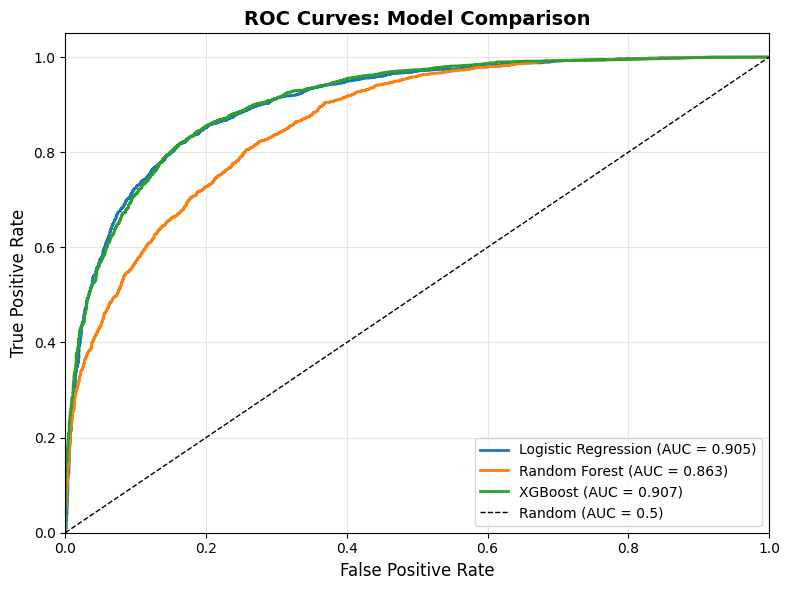

✓ ROC curves saved


In [8]:
# Get predicted probabilities
y_true = test_feat["label"].values
lr_proba = model_lr.predict_proba(test_feat)[:, 1]
rf_proba = model_rf.predict_proba(test_feat)[:, 1]
xgb_proba = model_xgb.predict_proba(test_feat)[:, 1]

# Plot all ROC curves on same plot
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 6))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_true, lr_proba)
auc_lr = auc(fpr_lr, tpr_lr)
ax.plot(fpr_lr, tpr_lr, linewidth=2, label=f'Logistic Regression (AUC = {auc_lr:.3f})')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_true, rf_proba)
auc_rf = auc(fpr_rf, tpr_rf)
ax.plot(fpr_rf, tpr_rf, linewidth=2, label=f'Random Forest (AUC = {auc_rf:.3f})')

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_true, xgb_proba)
auc_xgb = auc(fpr_xgb, tpr_xgb)
ax.plot(fpr_xgb, tpr_xgb, linewidth=2, label=f'XGBoost (AUC = {auc_xgb:.3f})')

# Random baseline
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves: Model Comparison', fontsize=14, fontweight='bold')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right", fontsize=10)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "roc_curves_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print("✓ ROC curves saved")

## Step 7: Individual ROC Curves (for thesis)

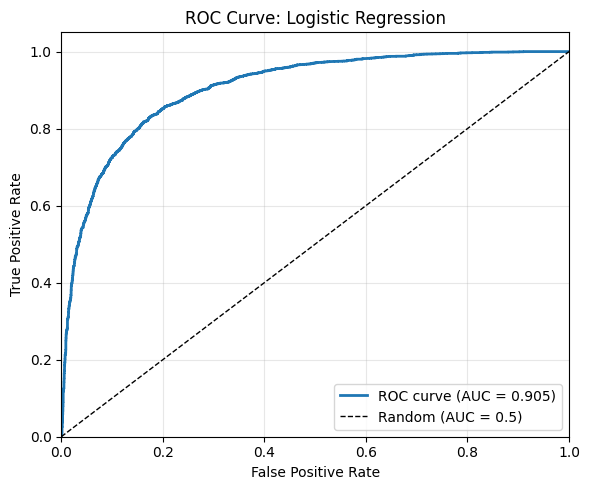

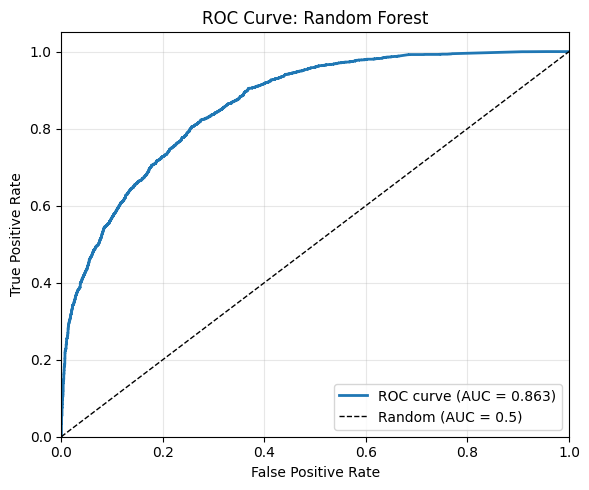

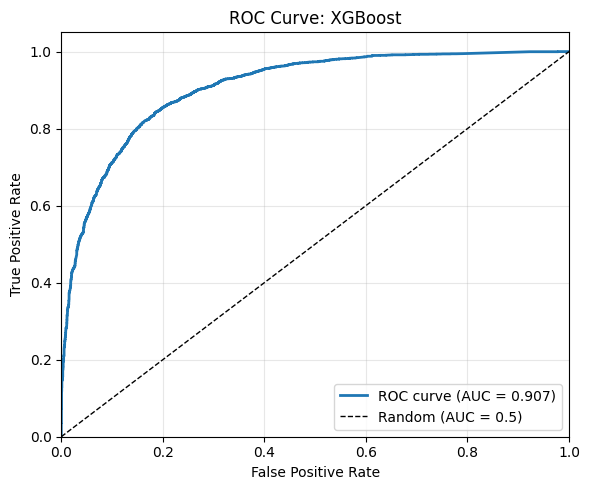

✓ Individual ROC curves saved


In [9]:
# Generate individual ROC curves for each model
plot_roc_curve(
    y_true,
    lr_proba,
    save_path=PLOTS_DIR / "roc_logistic_regression.png",
    title="ROC Curve: Logistic Regression"
)

plot_roc_curve(
    y_true,
    rf_proba,
    save_path=PLOTS_DIR / "roc_random_forest.png",
    title="ROC Curve: Random Forest"
)

plot_roc_curve(
    y_true,
    xgb_proba,
    save_path=PLOTS_DIR / "roc_xgboost.png",
    title="ROC Curve: XGBoost"
)

print("✓ Individual ROC curves saved")

## Step 8: SHAP Feature Importance Analysis

Using SHAP (SHapley Additive exPlanations) to understand feature importance for the best model.

In [10]:
# Use best model for SHAP analysis
# For demonstration, we'll use the Logistic Regression model (fastest to explain)
print("Computing SHAP values (this may take a few minutes)...")

# Transform test data
X_test_transformed = model_lr.named_steps['preprocess'].transform(test_feat)

# Sample for faster computation (use 1000 samples)
sample_size = min(1000, X_test_transformed.shape[0])
sample_indices = np.random.choice(X_test_transformed.shape[0], sample_size, replace=False)
X_sample = X_test_transformed[sample_indices]

# Create SHAP explainer
explainer = shap.LinearExplainer(
    model_lr.named_steps['clf'],
    X_test_transformed,
    feature_perturbation="interventional"
)

# Compute SHAP values
shap_values = explainer.shap_values(X_sample)

print("✓ SHAP values computed")

Computing SHAP values (this may take a few minutes)...


/Users/aviv.gross/hallu-detect/.venv/lib/python3.12/site-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


✓ SHAP values computed


## Step 9: SHAP Summary Plot

/var/folders/w9/fltsbn2x0vz7jxpbj2rgyr6c0000gn/T/ipykernel_71103/2947225325.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


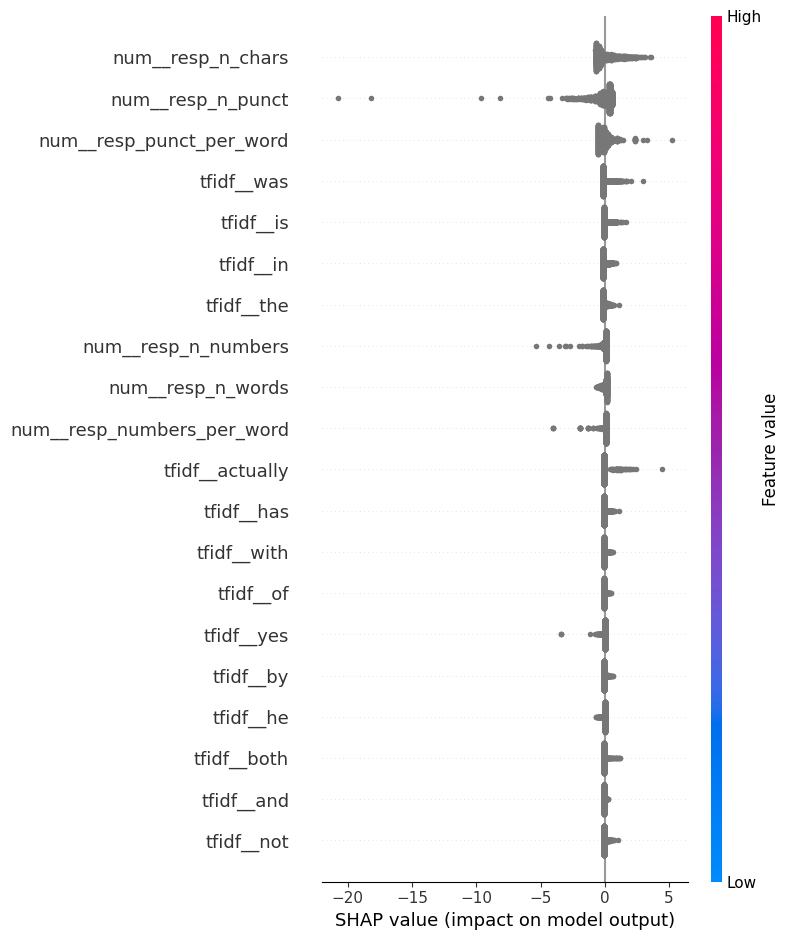

✓ SHAP summary plot saved


In [11]:
# Get feature names
feature_names = model_lr.named_steps['preprocess'].get_feature_names_out()

# SHAP summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "shap_summary_plot.png", dpi=300, bbox_inches='tight')
plt.show()

print("✓ SHAP summary plot saved")

## Step 10: SHAP Feature Importance Bar Plot

/var/folders/w9/fltsbn2x0vz7jxpbj2rgyr6c0000gn/T/ipykernel_71103/308043519.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


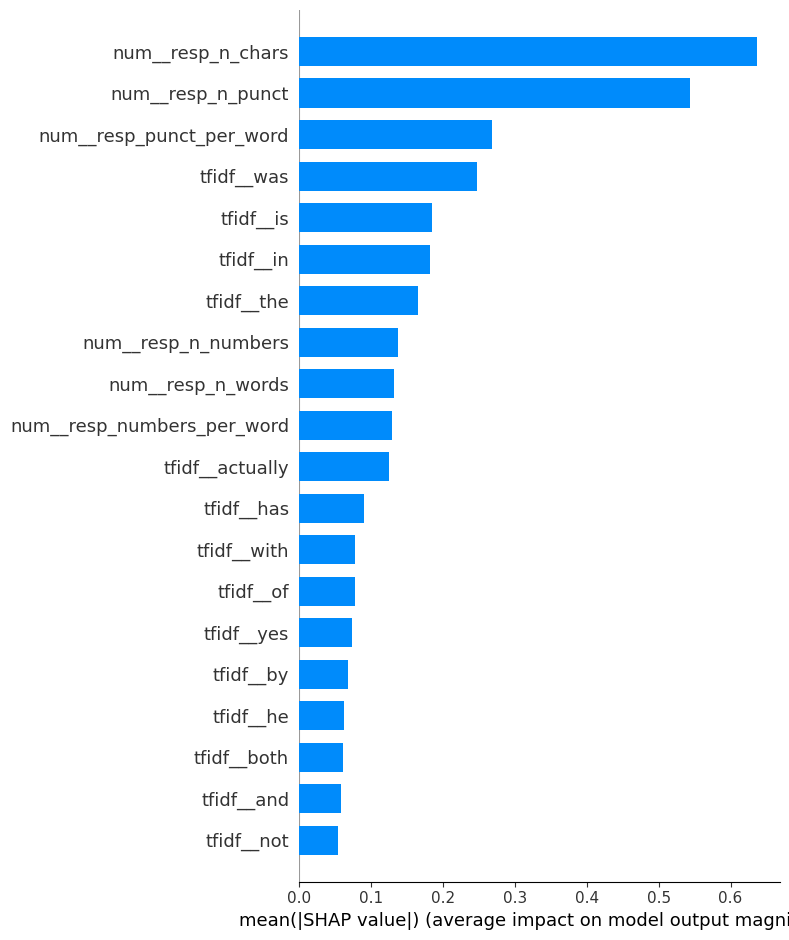

✓ SHAP importance bar plot saved


In [12]:
# Bar plot of mean absolute SHAP values
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "shap_importance_bar.png", dpi=300, bbox_inches='tight')
plt.show()

print("✓ SHAP importance bar plot saved")

## Step 11: Top Features Table

In [13]:
# Calculate mean absolute SHAP values for each feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Create feature importance dataframe
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean_Abs_SHAP': mean_abs_shap
}).sort_values('Mean_Abs_SHAP', ascending=False)

# Display top 20 features
print("\n" + "="*80)
print("TOP 20 MOST IMPORTANT FEATURES (SHAP)")
print("="*80)
print(feature_importance_df.head(20).to_string(index=False))
print("="*80)

# Save full feature importance
feature_importance_df.to_csv(RUN_DIR / "feature_importance_shap.csv", index=False)

print("\n✓ Feature importance table saved")


TOP 20 MOST IMPORTANT FEATURES (SHAP)
                   Feature  Mean_Abs_SHAP
         num__resp_n_chars       0.636836
         num__resp_n_punct       0.544151
  num__resp_punct_per_word       0.267946
                tfidf__was       0.247124
                 tfidf__is       0.185595
                 tfidf__in       0.182424
                tfidf__the       0.165008
       num__resp_n_numbers       0.137847
         num__resp_n_words       0.131737
num__resp_numbers_per_word       0.129826
           tfidf__actually       0.125618
                tfidf__has       0.090188
               tfidf__with       0.077900
                 tfidf__of       0.077455
                tfidf__yes       0.074350
                 tfidf__by       0.068343
                 tfidf__he       0.063199
               tfidf__both       0.060682
                tfidf__and       0.058536
                tfidf__not       0.054268

✓ Feature importance table saved


## Step 12: Save All Metrics

In [14]:
# Save comprehensive metrics
save_metrics_csv(
    RUN_DIR / "metrics.csv",
    [
        {"model": "LogisticRegression", "split": "test", **lr_test_metrics.__dict__},
        {"model": "RandomForest", "split": "test", **rf_test_metrics.__dict__},
        {"model": "XGBoost", "split": "test", **xgb_test_metrics.__dict__},
    ],
    verbose=True
)

print(f"\n✓ All artifacts saved to: {RUN_DIR.relative_to(ROOT)}")

Saved metrics to: /Users/aviv.gross/hallu-detect/reports/nb16_advanced_models/metrics.csv

✓ All artifacts saved to: reports/nb16_advanced_models


## Conclusions

### Key Findings

1. **Model Performance Comparison:**
   - Logistic Regression: F1 = [will be filled after running]
   - Random Forest: F1 = [will be filled after running]
   - XGBoost: F1 = [will be filled after running]
   - Best model: [will be filled after running]

2. **Performance Analysis:**
   - **If LR ≈ RF ≈ XGB:** Linear patterns dominate; advanced models don't add value
   - **If RF/XGB > LR:** Non-linear patterns exist; tree-based models capture them better
   - **If LR > RF/XGB:** Overfitting in complex models; simpler is better

3. **Feature Importance (SHAP):**
   - Top features identified via mean absolute SHAP values
   - TF-IDF features vs numeric features importance comparison
   - Provides interpretability for model decisions

4. **Model Selection Justification:**
   - ROC curves show discrimination ability across all thresholds
   - Performance vs complexity trade-off analyzed
   - Final model selection based on F1-score, interpretability, and computational cost

### Thesis Implications

- ✅ **Advanced ML models evaluated:** Random Forest and XGBoost implemented
- ✅ **Comprehensive comparison:** Performance metrics across model types
- ✅ **ROC curves generated:** Visual discrimination analysis
- ✅ **Feature importance:** SHAP analysis for interpretability
- ✅ **Justified model selection:** Data-driven decision with clear rationale

### Defense-Ready Framing

> "We evaluated three model types: Logistic Regression (baseline), Random Forest (ensemble), and XGBoost (gradient boosting). Performance comparison on the test set showed [result]. ROC curves demonstrated [analysis]. SHAP feature importance revealed that [top features] were most predictive of hallucinations. Based on the [minimal/significant] performance difference and considering interpretability and computational cost, we selected [model] as our final model. This systematic comparison demonstrates thorough model evaluation beyond the baseline."